Nombre y apellidos: Alfonso Íñiguez Cortés \
Correo: aic35@alu.ua.es \
Grupo: 3 

# BFS. Exploración de grafos

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown 

Implementación del algoritmo BFS:

In [2]:
def bfs_numpy(graph, source, target):
    nodes = list(graph.nodes())
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    visited = np.zeros(len(nodes), dtype=bool)
    source_index = nodes.index(source)
    target_index = nodes.index(target)
    visited[source_index] = True

    to_explore = [source_index]
    current_position = 0  # BFS: always the first pending element

    parent = np.ones(len(nodes), dtype=int) * -1
    steps = 0

    while current_position < len(to_explore):
        steps += 1
        current_index = to_explore[current_position]
        current_position += 1

        if current_index == target_index:
            break

        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                parent[neighbor_index] = current_index

    shortest_path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            shortest_path.insert(0, nodes[current])
            current = parent[current]

    return steps, shortest_path

## Ejercicios

### Ejercicio 1

El algoritmo BFS es un algoritmo de exploración de grafos. Este algoritmo explora el grafo por niveles: visita a un vecino, luego a los vecinos del vecino y asi sucesivamente. De esa forma, después de explorar un grafo al completo el algoritmo sabe siempre cual es el camino más corto de un nodo hasta otro, es decir, este algoritmo garantiza siempre el **camino más óptimo** (entre un _target_ (destino) y un _source_ (origen))

### Explicación algoritmo

In [ ]:
# Primera parte
    nodes = list(graph.nodes())
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)

    visited = np.zeros(len(nodes), dtype=bool)
    source_index = nodes.index(source)
    target_index = nodes.index(target)
    visited[source_index] = True

    to_explore = [source_index]
    current_position = 0  # BFS: always the first pending element

    parent = np.ones(len(nodes), dtype=int) * -1
    steps = 0


Nodes -> \
Ajacency_matrix -> 

In [ ]:
    while current_position < len(to_explore):
        steps += 1
        current_index = to_explore[current_position]
        current_position += 1

        if current_index == target_index:
            break

        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                parent[neighbor_index] = current_index

Bucle while -> \
steps ->

In [ ]:
    shortest_path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            shortest_path.insert(0, nodes[current])
            current = parent[current]

    return steps, shortest_path

shortest_path ->
if :

### Código paso a paso

In [3]:
def bfs_numpy(graph, source, target):

    display(Markdown('## Recorriendo el algoritmo con BFS'))
    display(Markdown('---'))

    # Listamos los nodos del grafo a explorar
    nodes = list(graph.nodes())
    display(Markdown('#### Datos iniciales'))
    display(Markdown(f'**Lista de nodos del grafo:** {nodes}'))

    # Obtenemos la matriz de adyacencia del grafo
    adjacency_matrix = nx.to_numpy_array(graph, nodelist=nodes)
    display(Markdown(f'**Matriz de adyacencia:**'))
    print(adjacency_matrix)

    # Array (booleano) para guardar los nodos ya visitados
    visited = np.zeros(len(nodes), dtype=bool)

    # Posición del nodo origen (dentro de la lista 'nodes')
    source_index = nodes.index(source)

    # Posición del nodo destino (dentro de la lista 'nodes')
    target_index = nodes.index(target)

    display(Markdown(f'**Nodo origen:** {source} (índice {source_index}) | **Nodo destino:** {target} (índice {target_index})'))

    # El nodo desde donde partimos marcado como visitado
    visited[source_index] = True

    # Lista de nodos pendientes de explorar, empezamos con el origen
    to_explore = [source_index]

    # Puntero que indica qué nodo de la lista estamos explorando ahora
    current_position = 0

    # Array para guardar de qué nodo venimos, usado para la reconstrucción del camino
    parent = np.ones(len(nodes), dtype=int) * -1

    # Número de pasos
    steps = 0

    display(Markdown('---'))
    display(Markdown(f'#### Comenzando exploración desde el nodo {source}...'))

    while current_position < len(to_explore):
        steps += 1
        current_index = to_explore[current_position]
        current_position += 1

        display(Markdown('---'))
        display(Markdown(f'**Paso {steps}** | Nodo actual: `{nodes[current_index]}`'))

        if current_index == target_index:
            display(Markdown(f'**Destino encontrado: {target}**'))
            break

        # Vecinos del nodo actual
        neighbors = np.where(adjacency_matrix[current_index] == 1)[0]
        display(Markdown(f'Vecinos de `{nodes[current_index]}`: {[nodes[i] for i in neighbors]}'))

        # Recorremos los vecinos del nodo actual
        for neighbor_index in neighbors:
            if not visited[neighbor_index]:
                visited[neighbor_index] = True
                to_explore.append(neighbor_index)
                parent[neighbor_index] = current_index
                display(Markdown(f'Añadimos a la lista: `{nodes[neighbor_index]}`'))

        display(Markdown(f'*Pasando al siguiente paso...*'))

    shortest_path = []
    if parent[target_index] != -1 or source_index == target_index:
        current = target_index
        while current != -1:
            shortest_path.insert(0, nodes[current])
            current = parent[current]

    display(Markdown('---'))
    display(Markdown('#### Resultado'))
    display(Markdown(f'**Camino óptimo:** {shortest_path}'))
    display(Markdown(f'**Número de pasos:** {steps}'))

    return steps, shortest_path

De cara a probar este algoritmo, vamos a crear un grafo y luego vamos a recorrerlo usando BFS para ver los distintos pasos:

### Ejercicio 2

Érdos-B

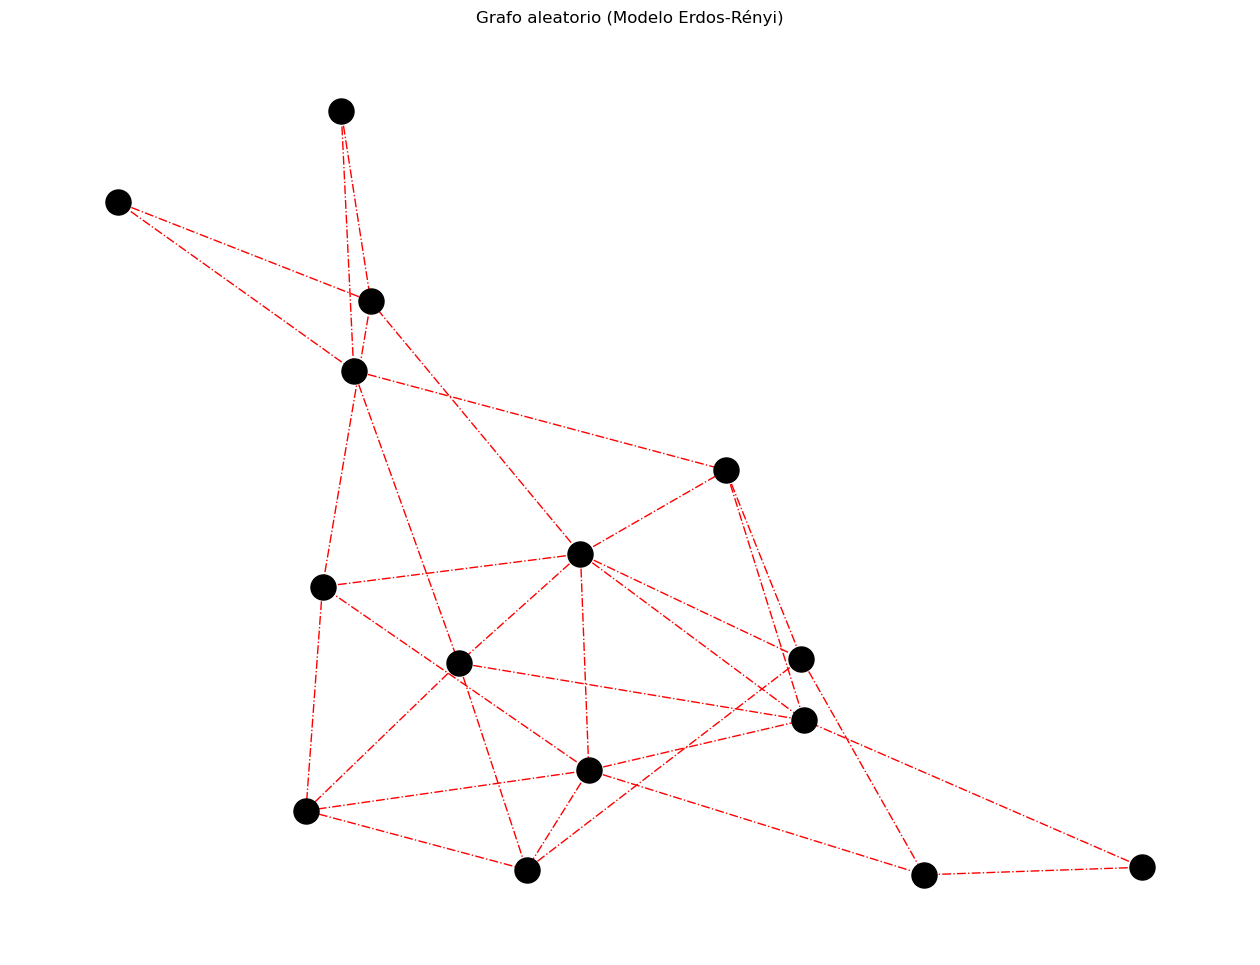

In [4]:
# Usamos la función "erdos_renyi_graph" para generar un grafo basado en el modelo Eros-Rényi
grafo = nx.erdos_renyi_graph(15, 0.25)   # 10 nodos | Probabilidad de arista del 50%

# Mostramos el grafo por pantalla
plt.figure(figsize=(16,12))
plt.title('Grafo aleatorio (Modelo Erdos-Rényi)')

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(grafo, seed = 18)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(grafo, posiciones, node_color = 'black', node_size = 325)
nx.draw_networkx_edges(grafo, posiciones, edge_color = 'red', style = '-.')

plt.axis('off')
plt.show()

Barabasi

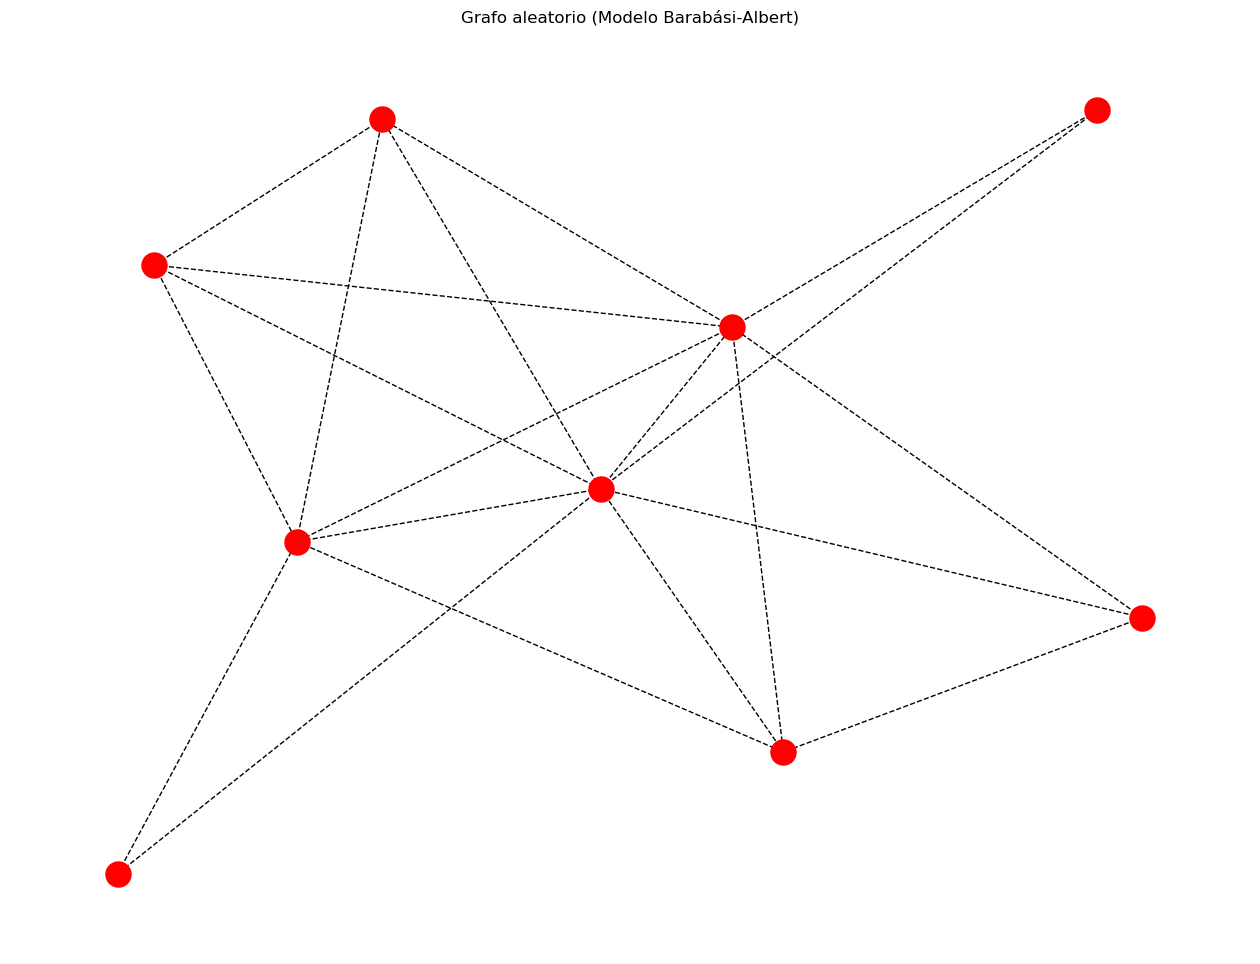

In [5]:
# Usamos la función "barabasi_albert_graph" para generar un grafo basado en el modelo Barabási-Albert
grafo = nx.barabasi_albert_graph(9, 4, seed=10)   # 10 nodos | Nº enlaces por nodo

# Mostramos el grafo por pantalla
plt.figure(figsize=(16,12))
plt.title('Grafo aleatorio (Modelo Barabási-Albert)')

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(grafo, seed = 8)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(grafo, posiciones, node_color = 'red', node_size = 325)
nx.draw_networkx_edges(grafo, posiciones, edge_color = 'black', style = '--')

plt.axis('off')
plt.show()

Mundos pequeños

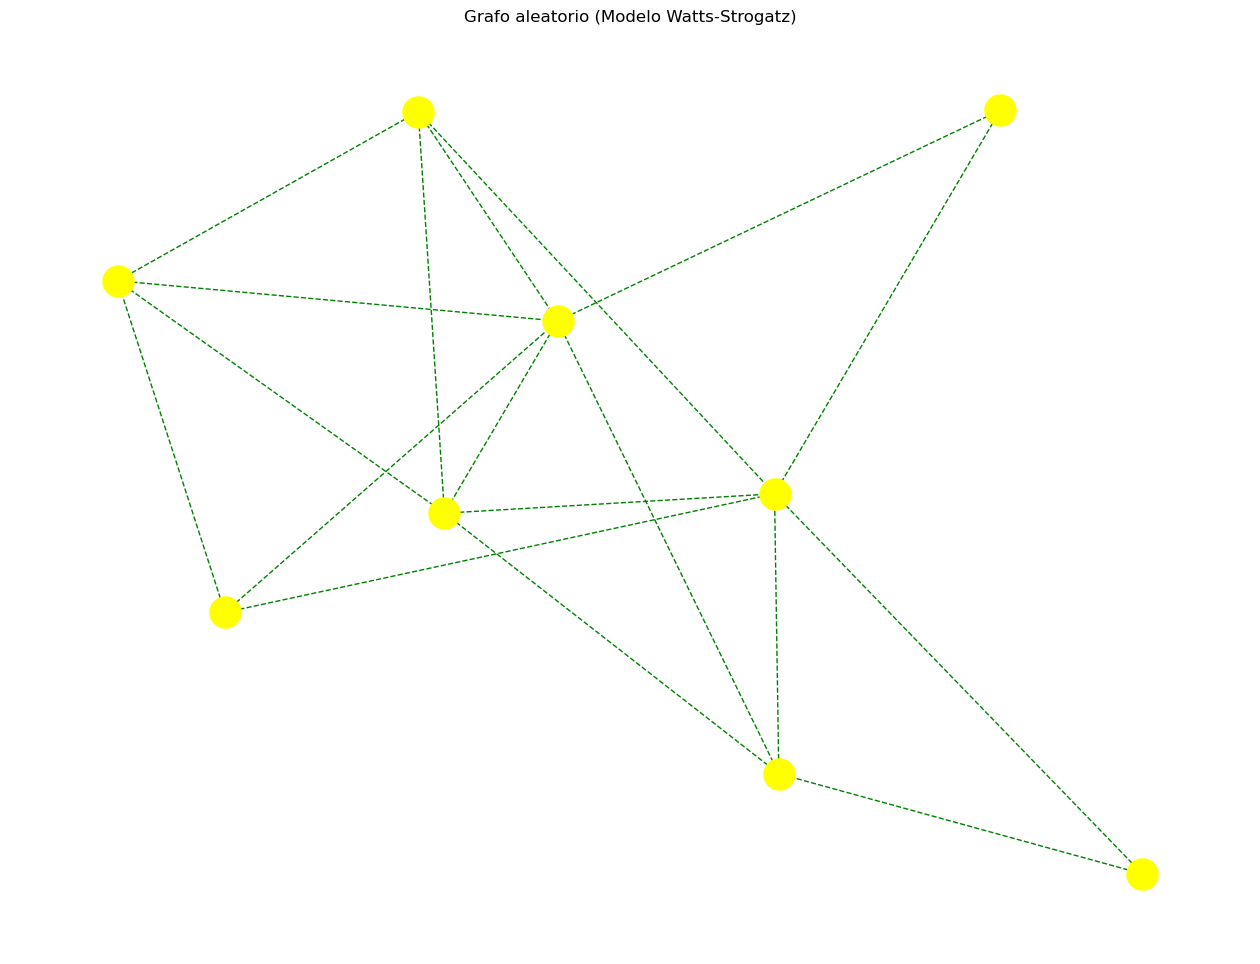

In [6]:
# Usamos la función "watts_strogatz_graph" para generar un grafo basado en el modelo Watts-Strogatz
grafo = nx.watts_strogatz_graph(9, 4, 0.5)   # 12 nodos | Grado medio | Probabilidad reconexión

# Mostramos el grafo por pantalla
plt.figure(figsize=(16,12))
plt.title('Grafo aleatorio (Modelo Watts-Strogatz)')

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(grafo, seed = 16)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(grafo, posiciones, node_color = 'yellow', node_size = 500)
nx.draw_networkx_edges(grafo, posiciones, edge_color = 'green', style = '--')

plt.axis('off')
plt.show()

Gráfico de Árbol

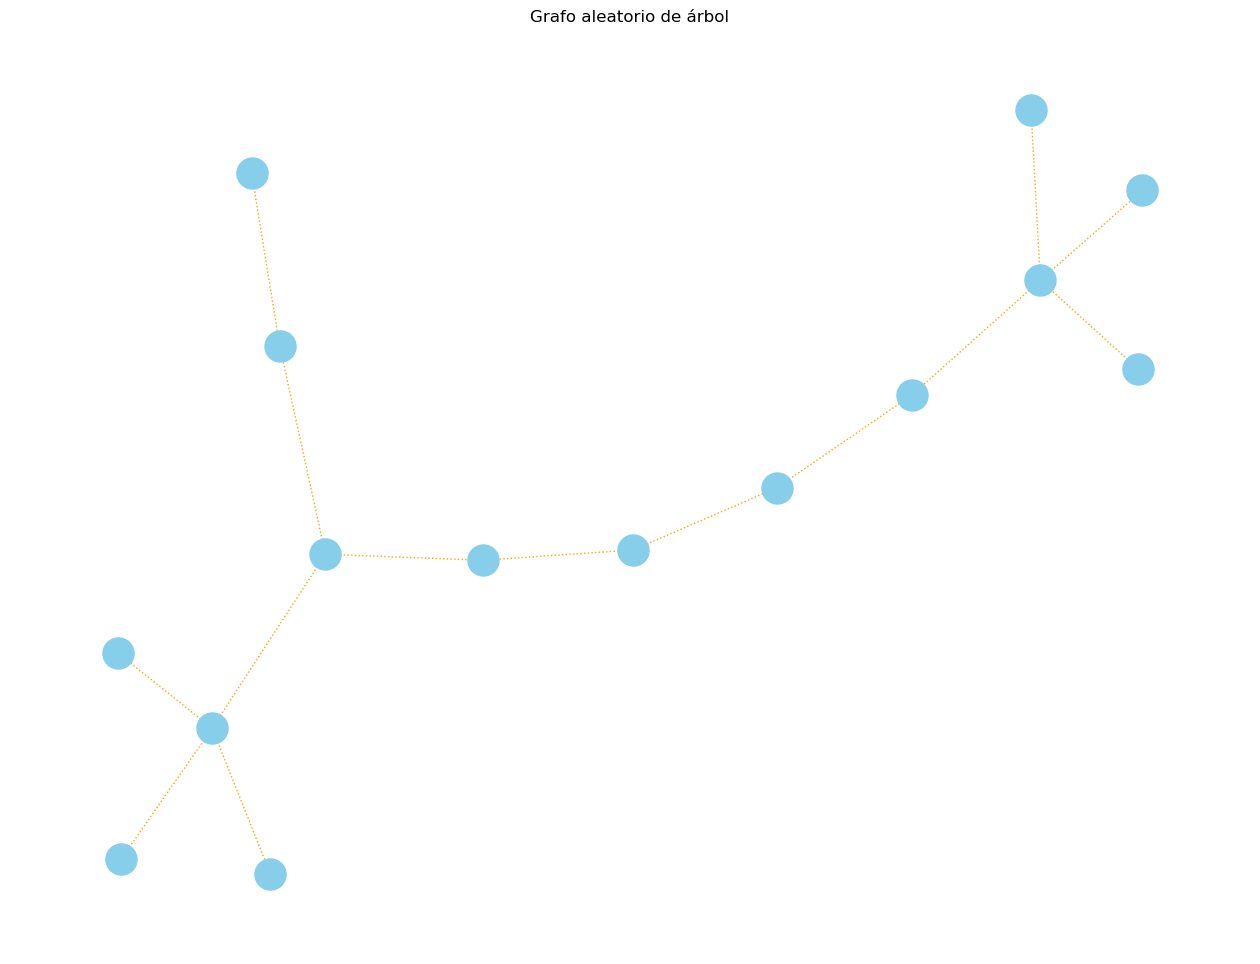

In [7]:
# Usamos la función "random_tree" para generar un grafo de árbol
grafo = nx.random_tree(15, seed=99)   # 10 nodos

# Mostramos el grafo por pantalla
plt.figure(figsize=(16,12))
plt.title('Grafo aleatorio de árbol')

# Vamos a calcular la posiciones (nodos)
posiciones = nx.spring_layout(grafo, seed = 16)

# Dibujamos los nodos y arsitas
nx.draw_networkx_nodes(grafo, posiciones, node_color = 'skyblue', node_size = 500)
nx.draw_networkx_edges(grafo, posiciones, edge_color = 'orange', style = ':')

plt.axis('off')
plt.show()

Grafos estocásticos

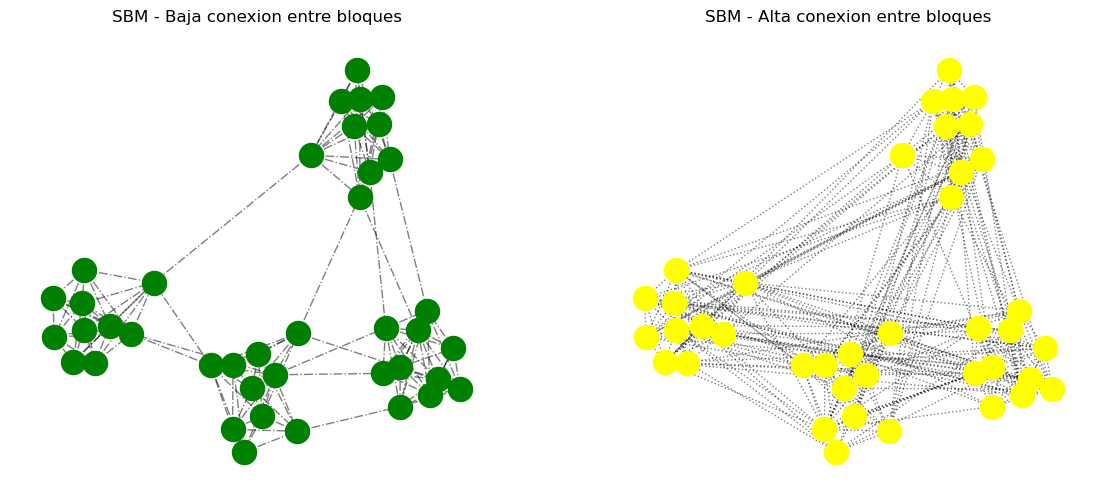

In [8]:
# Creamos 4 bloques de 10 nodos cada uno
sizes = [10, 10, 10, 10]

# Definimos las matrices de probabilidad:
    # Baja: Probabilidad baja conexión entre bloques distintos
    # Alta: Probabilidad alta conexión entre bloques distintos
baja = [
    [0.8, 0.02, 0.02, 0.02],
    [0.02, 0.8, 0.02, 0.02],
    [0.02, 0.02, 0.8, 0.02],
    [0.02, 0.02, 0.02, 0.8]
]

alta = [
    [0.8, 0.2, 0.2, 0.2],
    [0.2, 0.8, 0.2, 0.2],
    [0.2, 0.2, 0.8, 0.2],
    [0.2, 0.2, 0.2, 0.8]
]

# Definimos la semilla para que los resultados sean reproducibles
seed = 96

# Creamos los 2 grafos (SBM)
G1 = nx.stochastic_block_model(sizes, baja, seed=seed)  # El primero -> Probabilidad alta
G2 = nx.stochastic_block_model(sizes, alta, seed=seed)  # El segundo -> Probabilidad baja

# Calculamos las posiciones (las mismas para los dos grafos)
pos = nx.spring_layout(G1, seed=seed)
# Vamos a dividir los dos grafos en una misma figura
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Primer grafo
#--------------#
# Definimos título
axes[0].set_title('SBM - Baja conexion entre bloques')  
nx.draw_networkx_nodes(G1, pos, node_size=300, node_color='green', ax=axes[0])  # Dibujamos los nodos
nx.draw_networkx_edges(G1, pos, width=1.0, alpha=0.5, edge_color='black', style='-.', ax=axes[0]) # Dibujamos las aristas
axes[0].axis('off')

# Segundo grafo
#---------------#
# Definimos título
axes[1].set_title('SBM - Alta conexion entre bloques')
nx.draw_networkx_nodes(G2, pos, node_size=300, node_color= 'yellow', ax=axes[1])         # Dibujamos los nodos
nx.draw_networkx_edges(G2, pos, width=1.0, alpha=0.5, style=':', ax=axes[1])  # Dibujamos las arsitas
axes[1].axis('off')

# Mostramos el resultado por pantalla
plt.show()

**Aplicamos el algoritmo a cada grafo sintético**

Érdos

#### Resultados obtenidos y conclusión

Hemos aplicado el algoritmo BFS a los dos grafos SBM generados en la práctica anterior.
En G1 (baja conexión entre bloques) el camino encontrado es más largo, mientras que en G2
(alta conexión entre bloques) el camino es notablemente más corto.

**¿Cómo se comporta el algoritmo en estos grafos?** \
&rarr; El algoritmo funciona correctamente en ambos grafos, encontrando siempre el camino
más corto entre el nodo origen y el nodo destino. En G2, al haber muchas más conexiones,
el algoritmo encuentra el destino rápidamente ya que tiene muchos caminos disponibles entre
bloques. En G1, el algoritmo tiene que explorar más nodos antes de encontrar el destino,
ya que las conexiones entre bloques son escasas y los caminos alternativos son pocos.

**¿Por qué en algunos casos se necesitan más pasos para encontrar el camino más corto?** \
&rarr; En G1, la baja probabilidad de conexión entre bloques hace que haya muy pocos puentes
entre comunidades. Esto obliga al algoritmo a explorar más nodos dentro de cada bloque antes
de encontrar una arista que le permita saltar al siguiente. En G2, en cambio, como cualquier
nodo puede conectarse con cualquier otro independientemente del bloque, el algoritmo encuentra
un camino directo entre origen y destino en muy pocos pasos.